In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
# Load dataset
df = pd.read_csv('../data/katalog_gempa.csv')
print('Shape:', df.shape)
df.head()

Shape: (92887, 13)


,tgl,ot,lat,lon,depth,mag,remark,strike1,dip1,rake1,strike2,dip2,rake2
0,2008/11/01,21:02:43.058,-9.18,119.06,10,4.9,Sumba Region - Indonesia,NaN,NaN,NaN,NaN,NaN,NaN
1,2008/11/01,20:58:50.248,-6.55,129.64,10,4.6,Banda Sea,NaN,NaN,NaN,NaN,NaN,NaN
2,2008/11/01,17:43:12.941,-7.01,106.63,121,3.7,Java - Indonesia,NaN,NaN,NaN,NaN,NaN,NaN
3,2008/11/01,16:24:14.755,-3.30,127.85,10,3.2,Seram - Indonesia,NaN,NaN,NaN,NaN,NaN,NaN
4,2008/11/01,16:20:37.327,-6.41,129.54,70,4.3,Banda Sea,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92887 entries, 0 to 92886
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   tgl      92887 non-null  object 
 1   ot       92887 non-null  object 
 2   lat      92887 non-null  float64
 3   lon      92887 non-null  float64
 4   depth    92887 non-null  int64  
 5   mag      92887 non-null  float64
 6   remark   92887 non-null  object 
 7   strike1  2735 non-null   float64
 8   dip1     2735 non-null   float64
 9   rake1    2735 non-null   float64
 10  strike2  2735 non-null   float64
 11  dip2     2735 non-null   float64
 12  rake2    2735 non-null   float64
dtypes: float64(9), int64(1), object(3)
memory usage: 9.2+ MB


In [4]:
# Cek missing values & statistik deskriptif
print('Missing values:')
print(df.isnull().sum())
print('\nStatistik deskriptif:')
df.describe()


Missing values:
tgl            0
ot             0
lat            0
lon            0
depth          0
mag            0
remark         0
strike1    90152
dip1       90152
rake1      90152
strike2    90152
dip2       90152
rake2      90152
dtype: int64

Statistik deskriptif:


,lat,lon,depth,mag,strike1,dip1,rake1,strike2,dip2,rake2
count,92887.000000,92887.000000,92887.000000,92887.000000,2735.000000,2735.000000,2735.000000,2735.000000,2735.000000,2735.000000
mean,-3.404577,119.159707,49.009399,3.592788,170.142852,60.202121,30.358062,197.450303,56.576344,35.250018
std,4.354584,10.833202,76.761070,0.834042,88.359267,19.699252,99.957906,118.920519,21.274923,98.235894
min,-11.000000,94.020000,2.000000,1.000000,0.000000,2.300000,-180.000000,0.000000,1.500000,-180.000000
25%,-7.885000,113.170000,10.000000,3.000000,107.550000,46.950000,-28.500000,63.115000,39.400000,-19.900000
50%,-2.910000,121.160000,16.000000,3.500000,144.600000,62.300000,57.600000,240.720000,58.400000,56.500000
75%,0.140000,126.900000,54.000000,4.200000,217.500000,76.400000,100.150000,297.480000,74.700000,112.600000
max,6.000000,142.000000,750.000000,7.900000,359.200000,90.000000,180.000000,359.980000,90.000000,180.000000


In [5]:
# Drop rows dengan missing values di kolom penting
df_clean = df[['lat', 'lon', 'depth', 'mag']].dropna()
print('Shape setelah cleaning:', df_clean.shape)
print('Missing values setelah cleaning:')
print(df_clean.isnull().sum())
df_clean.head()


Shape setelah cleaning: (92887, 4)
Missing values setelah cleaning:
lat      0
lon      0
depth    0
mag      0
dtype: int64


,lat,lon,depth,mag
0,-9.18,119.06,10,4.9
1,-6.55,129.64,10,4.6
2,-7.01,106.63,121,3.7
3,-3.30,127.85,10,3.2
4,-6.41,129.54,70,4.3


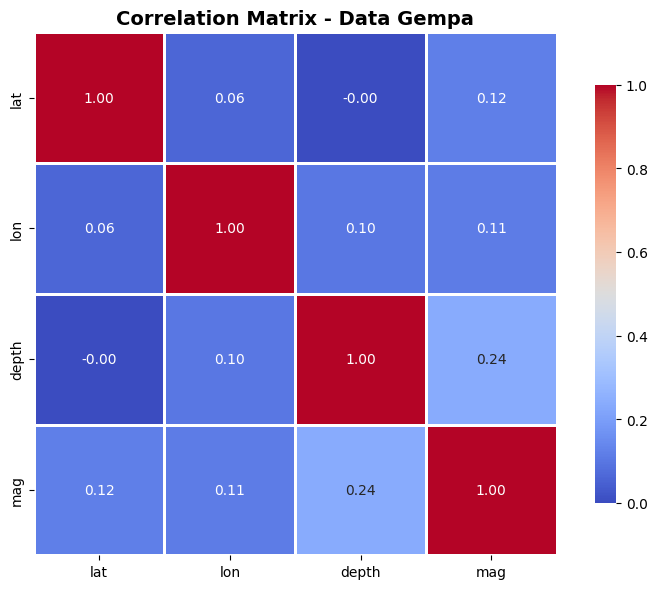


Korelasi antar fitur:
            lat       lon     depth       mag
lat    1.000000  0.060283 -0.000180  0.118029
lon    0.060283  1.000000  0.100506  0.109827
depth -0.000180  0.100506  1.000000  0.235087
mag    0.118029  0.109827  0.235087  1.000000


In [6]:
# Correlation matrix untuk melihat hubungan antar fitur
correlation_matrix = df_clean.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Data Gempa', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKorelasi antar fitur:')
print(correlation_matrix)


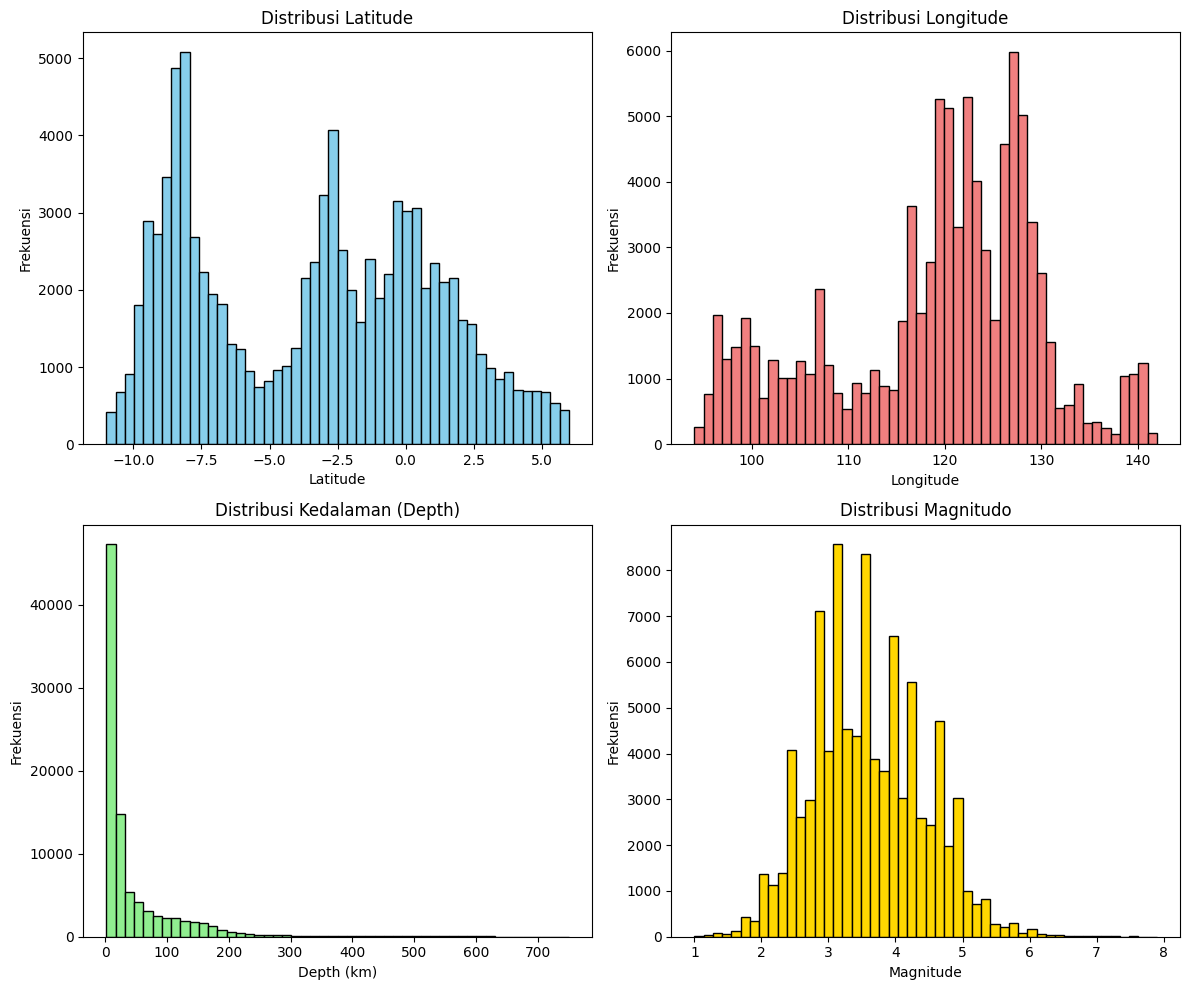

In [7]:
# Visualisasi distribusi data
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(df_clean['lat'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribusi Latitude')
axes[0, 0].set_xlabel('Latitude')
axes[0, 0].set_ylabel('Frekuensi')

axes[0, 1].hist(df_clean['lon'], bins=50, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Distribusi Longitude')
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Frekuensi')

axes[1, 0].hist(df_clean['depth'], bins=50, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Distribusi Kedalaman (Depth)')
axes[1, 0].set_xlabel('Depth (km)')
axes[1, 0].set_ylabel('Frekuensi')

axes[1, 1].hist(df_clean['mag'], bins=50, color='gold', edgecolor='black')
axes[1, 1].set_title('Distribusi Magnitudo')
axes[1, 1].set_xlabel('Magnitude')
axes[1, 1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()


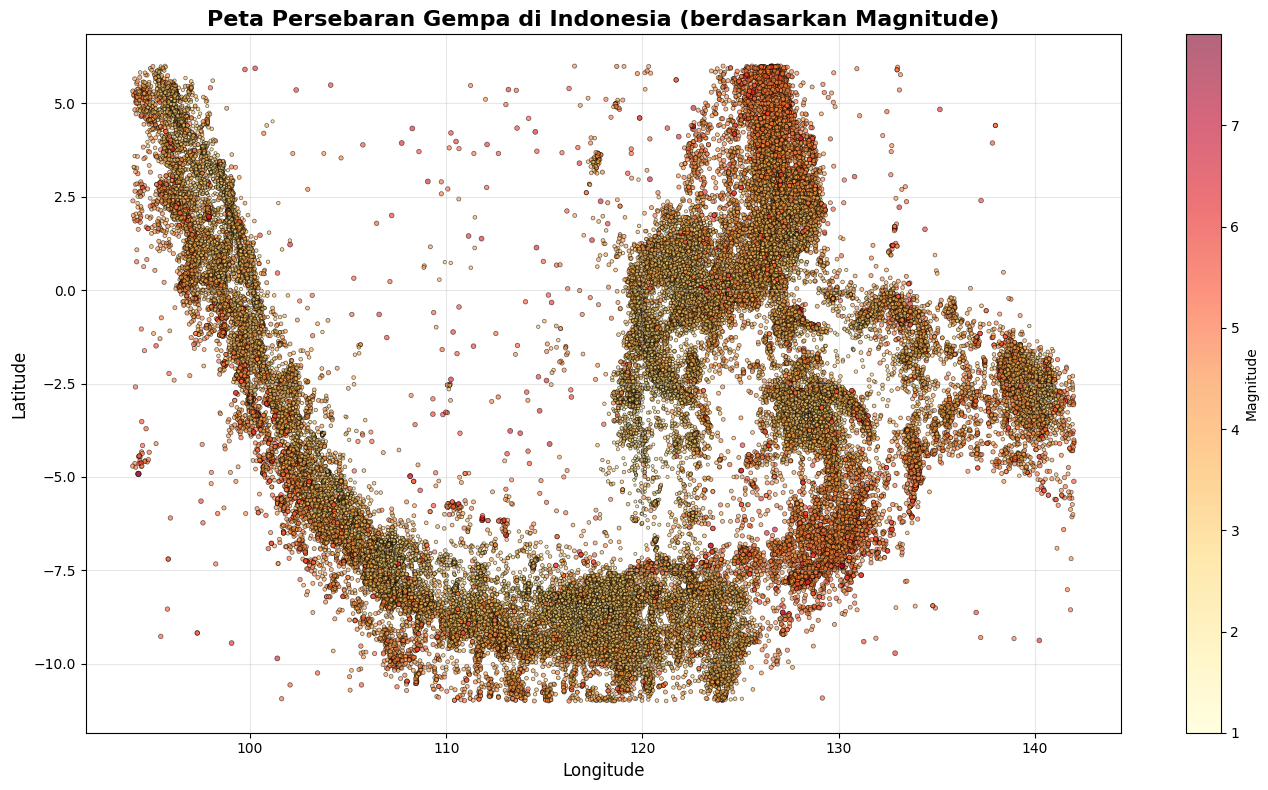

In [8]:
# Visualisasi Peta Persebaran Gempa (sebelum clustering)
plt.figure(figsize=(14, 8))
plt.scatter(df_clean['lon'], df_clean['lat'], 
           c=df_clean['mag'], cmap='YlOrRd', 
           s=df_clean['mag']*2, alpha=0.6, edgecolors='black', linewidth=0.5)
plt.colorbar(label='Magnitude')
plt.title('Peta Persebaran Gempa di Indonesia (berdasarkan Magnitude)', fontsize=16, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [9]:
np.random.seed(42)
sample_size = 10000
df_sample = df_clean.sample(n=min(sample_size, len(df_clean)), random_state=42)
print(f'Sample size untuk DBSCAN: {len(df_sample)}')
df_sample.head()


Sample size untuk DBSCAN: 10000


,lat,lon,depth,mag
61672,5.05,127.10,30,5.0
82692,-0.79,121.55,10,2.9
39586,0.55,126.17,10,2.9
4063,-9.68,114.02,10,4.4
68243,-8.44,116.27,78,2.8


In [10]:
# Normalisasi data dengan StandardScaler
X = df_sample[['lat', 'lon', 'depth', 'mag']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Data scaled (first 5 rows):')
print(X_scaled[:5])
print('\nShape X_scaled:', X_scaled.shape)


Data scaled (first 5 rows):
[[ 1.97529931  0.74831832 -0.24216149  1.66218259]
 [ 0.6320291   0.23450007 -0.50057597 -0.83723271]
 [ 0.94024521  0.66221904 -0.50057597 -0.83723271]
 [-1.41277777 -0.4626263  -0.50057597  0.94806393]
 [-1.12756286 -0.25432161  0.37803324 -0.95625249]]

Shape X_scaled: (10000, 4)


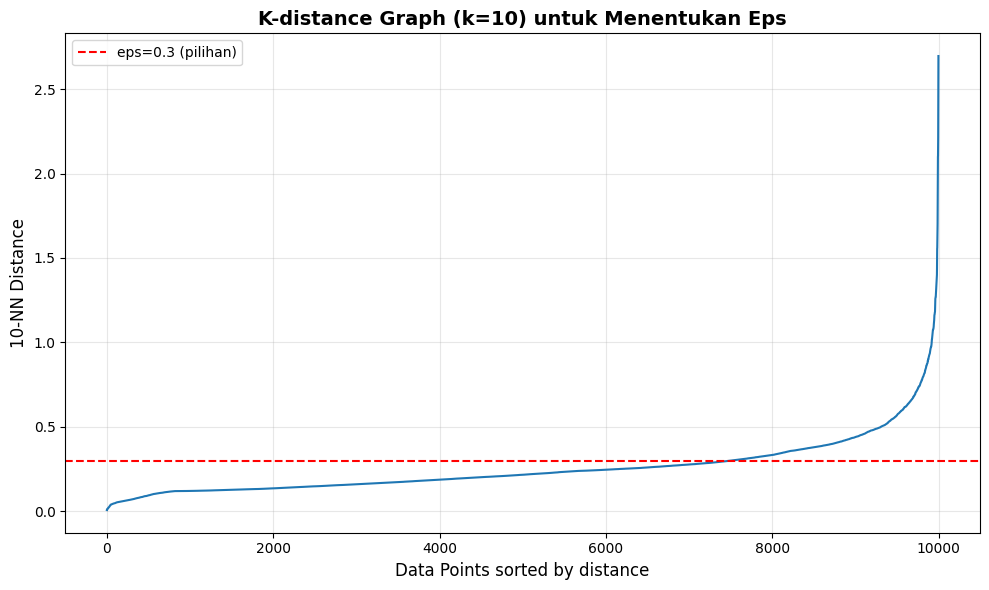

Rekomendasi eps: lihat "elbow" pada grafik di atas
Nilai eps yang dipilih: 0.3


In [11]:
# K-distance graph untuk menentukan eps optimal
from sklearn.neighbors import NearestNeighbors

# Gunakan k = min_samples yang akan dipakai (misal 10)
k = 10
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_scaled)

# Hitung jarak ke k-nearest neighbor
distances, indices = neighbors.kneighbors(X_scaled)

# Sort jarak ke k-nearest neighbor (kolom terakhir)
distances_k = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances_k)
plt.xlabel('Data Points sorted by distance', fontsize=12)
plt.ylabel(f'{k}-NN Distance', fontsize=12)
plt.title(f'K-distance Graph (k={k}) untuk Menentukan Eps', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.3, color='r', linestyle='--', label='eps=0.3 (pilihan)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Rekomendasi eps: lihat "elbow" pada grafik di atas')
print(f'Nilai eps yang dipilih: 0.3')


In [12]:
dbscan = DBSCAN(eps=0.3, min_samples=10)
clusters = dbscan.fit_predict(X_scaled)

df_sample['Cluster'] = clusters

print('Jumlah cluster yang terbentuk:', len(set(clusters)) - (1 if -1 in clusters else 0))
print('Jumlah noise points (cluster -1):', list(clusters).count(-1))
print('\nDistribusi cluster:')
print(df_sample['Cluster'].value_counts().sort_index())


Jumlah cluster yang terbentuk: 8
Jumlah noise points (cluster -1): 1541

Distribusi cluster:
Cluster
-1    1541
 0    4101
 1    4038
 2     228
 3      16
 4      26
 5      20
 6      22
 7       8
Name: count, dtype: int64
 8
Jumlah noise points (cluster -1): 1541

Distribusi cluster:
Cluster
-1    1541
 0    4101
 1    4038
 2     228
 3      16
 4      26
 5      20
 6      22
 7       8
Name: count, dtype: int64


Perbandingan berbagai nilai eps:


,eps,n_clusters,n_noise,pct_noise
0,0.2,49,4084,40.84
1,0.3,8,1541,15.41
2,0.4,10,648,6.48
3,0.5,2,349,3.49


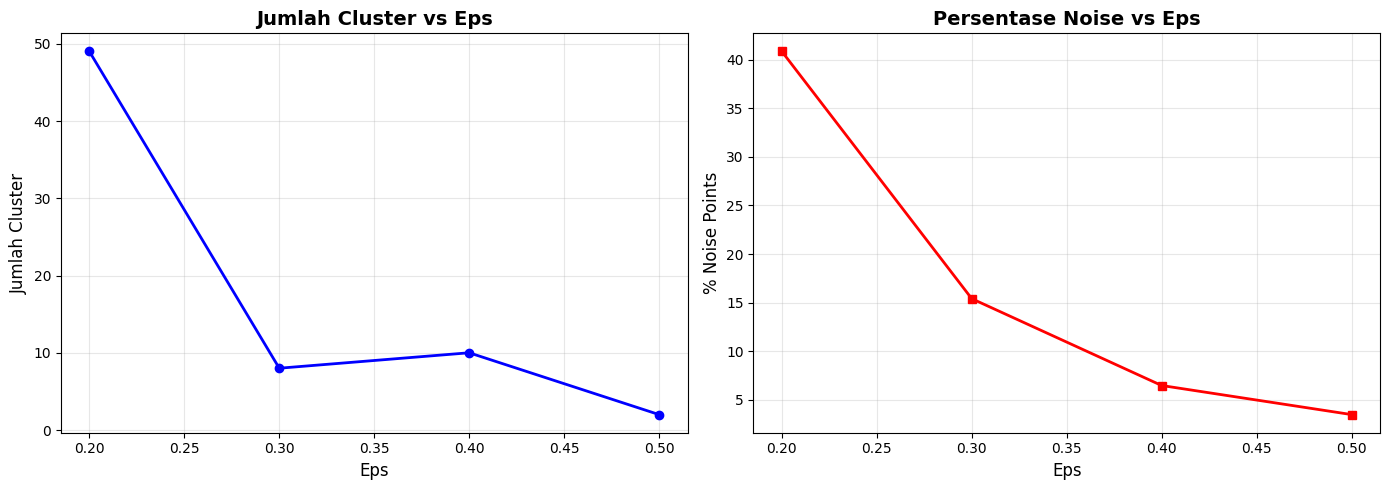

In [13]:
# Eksperimen dengan berbagai nilai eps
eps_values = [0.2, 0.3, 0.4, 0.5]
results = []

for eps_val in eps_values:
    dbscan_temp = DBSCAN(eps=eps_val, min_samples=10)
    clusters_temp = dbscan_temp.fit_predict(X_scaled)
    
    n_clusters = len(set(clusters_temp)) - (1 if -1 in clusters_temp else 0)
    n_noise = list(clusters_temp).count(-1)
    
    results.append({
        'eps': eps_val,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'pct_noise': (n_noise / len(clusters_temp)) * 100
    })
    
results_df = pd.DataFrame(results)
print('Perbandingan berbagai nilai eps:')
display(results_df)

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df['eps'], results_df['n_clusters'], marker='o', color='blue', linewidth=2)
axes[0].set_xlabel('Eps', fontsize=12)
axes[0].set_ylabel('Jumlah Cluster', fontsize=12)
axes[0].set_title('Jumlah Cluster vs Eps', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(results_df['eps'], results_df['pct_noise'], marker='s', color='red', linewidth=2)
axes[1].set_xlabel('Eps', fontsize=12)
axes[1].set_ylabel('% Noise Points', fontsize=12)
axes[1].set_title('Persentase Noise vs Eps', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [14]:
# Evaluasi dengan Silhouette Score (hanya untuk cluster non-noise)
df_valid = df_sample[df_sample['Cluster'] != -1]
if len(df_valid) > 0 and len(df_valid['Cluster'].unique()) > 1:
    X_valid = df_valid[['lat', 'lon', 'depth', 'mag']].values
    X_valid_scaled = scaler.transform(X_valid)
    score = silhouette_score(X_valid_scaled, df_valid['Cluster'])
    print(f'Silhouette Score: {score:.4f}')
else:
    print('Tidak dapat menghitung Silhouette Score (cluster tidak valid)')


Silhouette Score: 0.0882


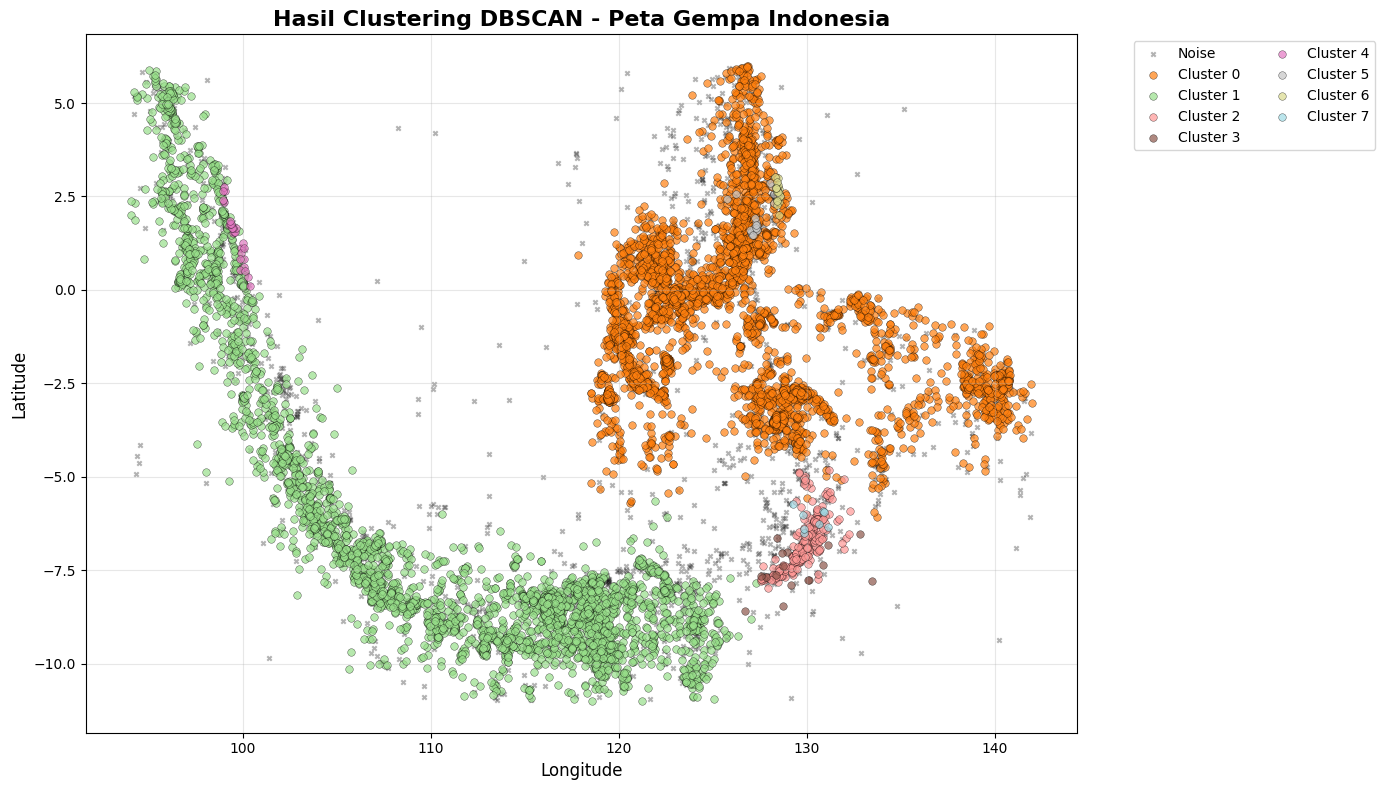

In [15]:
# Visualisasi Hasil Clustering pada Peta (Latitude vs Longitude)
plt.figure(figsize=(14, 8))

# Plot setiap cluster dengan warna berbeda
unique_clusters = sorted(df_sample['Cluster'].unique())
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_clusters)))

for i, cluster in enumerate(unique_clusters):
    cluster_data = df_sample[df_sample['Cluster'] == cluster]
    if cluster == -1:
        # Noise points (warna hitam)
        plt.scatter(cluster_data['lon'], cluster_data['lat'], 
                   c='black', s=10, alpha=0.3, label='Noise', marker='x')
    else:
        plt.scatter(cluster_data['lon'], cluster_data['lat'], 
                   c=[colors[i]], s=30, alpha=0.7, 
                   label=f'Cluster {cluster}', edgecolors='black', linewidth=0.3)

plt.title('Hasil Clustering DBSCAN - Peta Gempa Indonesia', fontsize=16, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


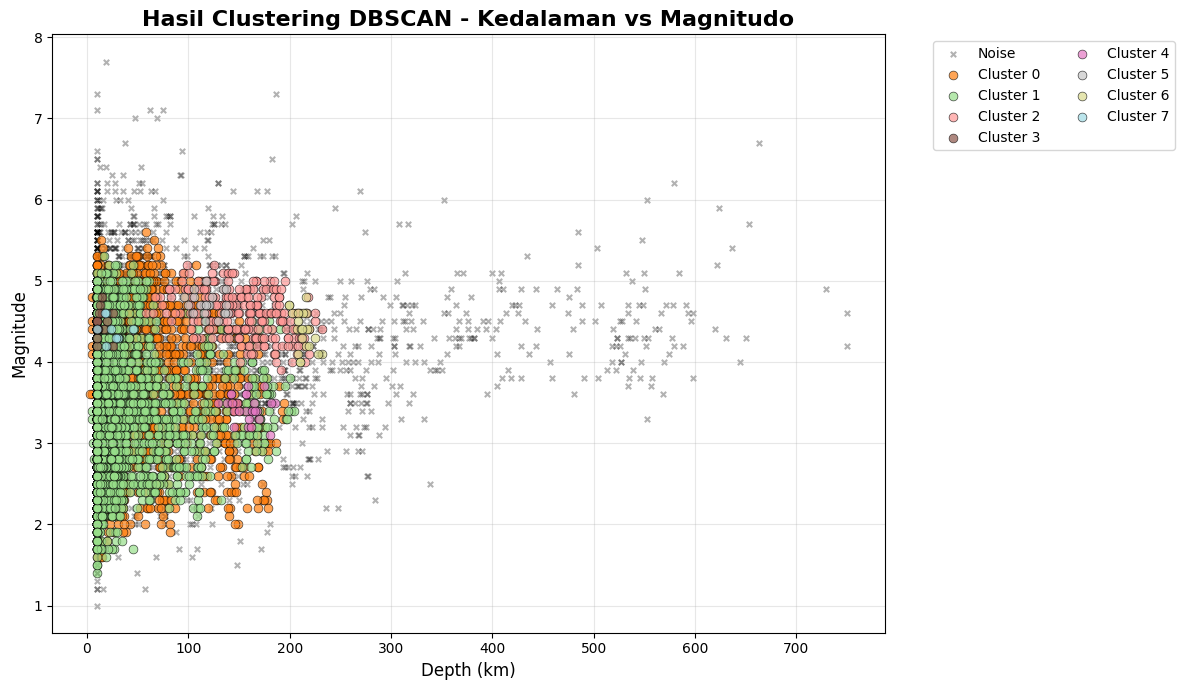

In [16]:
# Visualisasi Clustering berdasarkan Depth vs Magnitude
plt.figure(figsize=(12, 7))

for i, cluster in enumerate(unique_clusters):
    cluster_data = df_sample[df_sample['Cluster'] == cluster]
    if cluster == -1:
        plt.scatter(cluster_data['depth'], cluster_data['mag'], 
                   c='black', s=15, alpha=0.3, label='Noise', marker='x')
    else:
        plt.scatter(cluster_data['depth'], cluster_data['mag'], 
                   c=[colors[i]], s=40, alpha=0.7, 
                   label=f'Cluster {cluster}', edgecolors='black', linewidth=0.5)

plt.title('Hasil Clustering DBSCAN - Kedalaman vs Magnitudo', fontsize=16, fontweight='bold')
plt.xlabel('Depth (km)', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [17]:
# Statistik per cluster
print('Statistik per Cluster:\n')
for cluster in sorted(df_sample['Cluster'].unique()):
    if cluster != -1:
        cluster_data = df_sample[df_sample['Cluster'] == cluster]
        print(f'\n=== Cluster {cluster} ===')
        print(f'Jumlah gempa: {len(cluster_data)}')
        print(f'Rata-rata Latitude: {cluster_data["lat"].mean():.2f}')
        print(f'Rata-rata Longitude: {cluster_data["lon"].mean():.2f}')
        print(f'Rata-rata Depth: {cluster_data["depth"].mean():.2f} km')
        print(f'Rata-rata Magnitude: {cluster_data["mag"].mean():.2f}')
        print(f'Max Magnitude: {cluster_data["mag"].max():.2f}')


Statistik per Cluster:


=== Cluster 0 ===
Jumlah gempa: 4101
Rata-rata Latitude: -0.73
Rata-rata Longitude: 126.32
Rata-rata Depth: 27.82 km
Rata-rata Magnitude: 3.53
Max Magnitude: 5.60

=== Cluster 1 ===
Jumlah gempa: 4038
Rata-rata Latitude: -6.29
Rata-rata Longitude: 110.77
Rata-rata Depth: 26.03 km
Rata-rata Magnitude: 3.38
Max Magnitude: 5.30

=== Cluster 2 ===
Jumlah gempa: 228
Rata-rata Latitude: -6.74
Rata-rata Longitude: 129.83
Rata-rata Depth: 152.72 km
Rata-rata Magnitude: 4.60
Max Magnitude: 5.20

=== Cluster 3 ===
Jumlah gempa: 16
Rata-rata Latitude: -7.50
Rata-rata Longitude: 129.48
Rata-rata Depth: 14.06 km
Rata-rata Magnitude: 4.47
Max Magnitude: 4.80

=== Cluster 4 ===
Jumlah gempa: 26
Rata-rata Latitude: 1.45
Rata-rata Longitude: 99.60
Rata-rata Depth: 158.19 km
Rata-rata Magnitude: 3.44
Max Magnitude: 3.70

=== Cluster 5 ===
Jumlah gempa: 20
Rata-rata Latitude: 1.93
Rata-rata Longitude: 127.29
Rata-rata Depth: 119.75 km
Rata-rata Magnitude: 4.72
Max Magnitude: 5.00

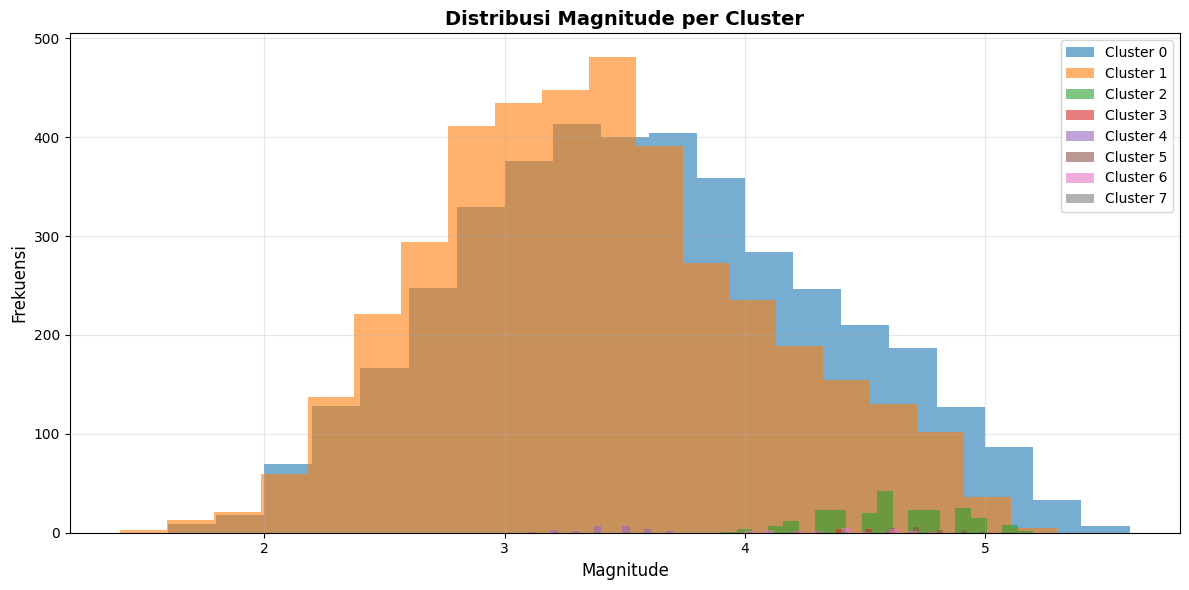

In [18]:
# Visualisasi distribusi magnitude per cluster
clusters_non_noise = df_sample[df_sample['Cluster'] != -1]

if len(clusters_non_noise) > 0:
    plt.figure(figsize=(12, 6))
    
    for cluster in sorted(clusters_non_noise['Cluster'].unique()):
        cluster_data = clusters_non_noise[clusters_non_noise['Cluster'] == cluster]
        plt.hist(cluster_data['mag'], bins=20, alpha=0.6, label=f'Cluster {cluster}')
    
    plt.xlabel('Magnitude', fontsize=12)
    plt.ylabel('Frekuensi', fontsize=12)
    plt.title('Distribusi Magnitude per Cluster', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


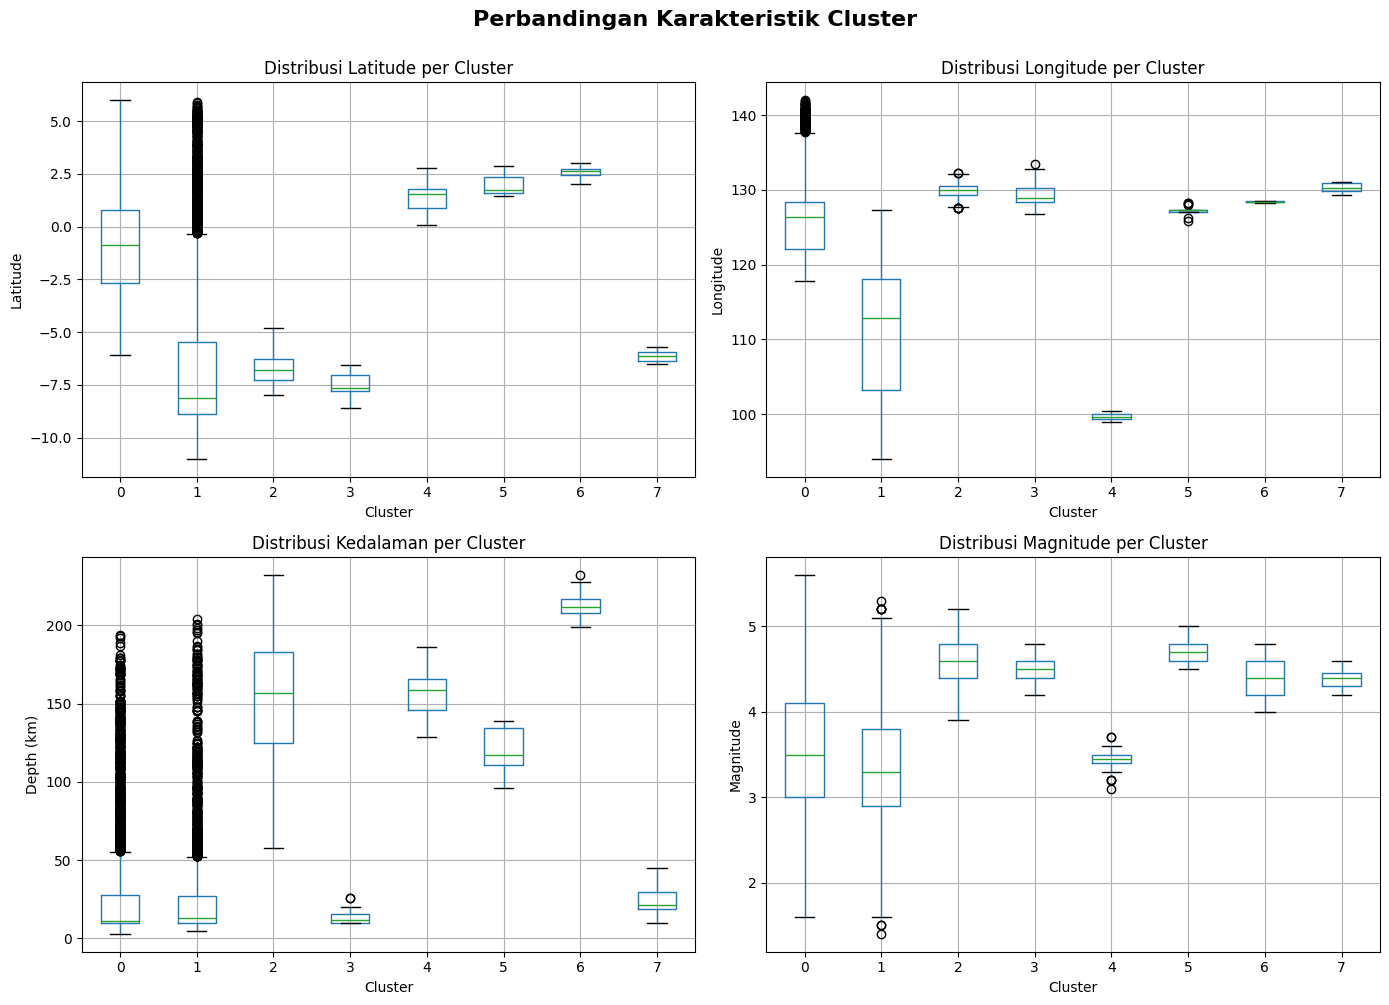

In [19]:
# Box plot untuk perbandingan karakteristik cluster
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

if len(clusters_non_noise) > 0:
    # Latitude
    clusters_non_noise.boxplot(column='lat', by='Cluster', ax=axes[0, 0])
    axes[0, 0].set_title('Distribusi Latitude per Cluster')
    axes[0, 0].set_xlabel('Cluster')
    axes[0, 0].set_ylabel('Latitude')
    
    # Longitude
    clusters_non_noise.boxplot(column='lon', by='Cluster', ax=axes[0, 1])
    axes[0, 1].set_title('Distribusi Longitude per Cluster')
    axes[0, 1].set_xlabel('Cluster')
    axes[0, 1].set_ylabel('Longitude')
    
    # Depth
    clusters_non_noise.boxplot(column='depth', by='Cluster', ax=axes[1, 0])
    axes[1, 0].set_title('Distribusi Kedalaman per Cluster')
    axes[1, 0].set_xlabel('Cluster')
    axes[1, 0].set_ylabel('Depth (km)')
    
    # Magnitude
    clusters_non_noise.boxplot(column='mag', by='Cluster', ax=axes[1, 1])
    axes[1, 1].set_title('Distribusi Magnitude per Cluster')
    axes[1, 1].set_xlabel('Cluster')
    axes[1, 1].set_ylabel('Magnitude')

plt.suptitle('Perbandingan Karakteristik Cluster', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


In [20]:
# Kesimpulan dan Interpretasi
print('KESIMPULAN CLUSTERING DBSCAN PADA DATA GEMPA')
print(f'\n1. Parameter DBSCAN yang digunakan:')
print(f'   - eps (epsilon): 0.3')
print(f'   - min_samples: 10')
print(f'\n2. Hasil Clustering:')
print(f'   - Total data: {len(df_sample)}')
print(f'   - Jumlah cluster terbentuk: {len(set(clusters)) - (1 if -1 in clusters else 0)}')
print(f'   - Jumlah noise points: {list(clusters).count(-1)} ({(list(clusters).count(-1)/len(clusters)*100):.2f}%)')

if len(df_valid) > 0 and len(df_valid['Cluster'].unique()) > 1:
    print(f'   - Silhouette Score: {score:.4f}')

print(f'\n3. Interpretasi:')
print(f'   - Cluster mengelompokkan gempa berdasarkan lokasi geografis (lat, lon)')
print(f'   - Kedalaman (depth) dan magnitude (mag) memberi karakteristik tambahan')
print(f'   - Noise points adalah gempa yang terisolasi/tidak membentuk kelompok padat')
print(f'   - Setiap cluster mewakili zona/kawasan rawan gempa dengan karakteristik serupa')



KESIMPULAN CLUSTERING DBSCAN PADA DATA GEMPA

1. Parameter DBSCAN yang digunakan:
   - eps (epsilon): 0.3
   - min_samples: 10

2. Hasil Clustering:
   - Total data: 10000
   - Jumlah cluster terbentuk: 8
   - Jumlah noise points: 1541 (15.41%)
   - Silhouette Score: 0.0882

3. Interpretasi:
   - Cluster mengelompokkan gempa berdasarkan lokasi geografis (lat, lon)
   - Kedalaman (depth) dan magnitude (mag) memberi karakteristik tambahan
   - Noise points adalah gempa yang terisolasi/tidak membentuk kelompok padat
   - Setiap cluster mewakili zona/kawasan rawan gempa dengan karakteristik serupa
